# Understanding a meta-harness: MemoRizz, read and run


A **harness** runs one model on one task: it assembles the context, runs the tools, keeps
the state and stops the model before it does harm. A **meta-harness** sits one level up.
It does not replace the vendor's agent loop; it puts a stable host contract around several
harnesses and normalises what goes in and what comes out: the task, the permissions, the
memory, the events, the result, the approval and the evidence. One control plane, many
agents.

MemoRizz implements one. This notebook reads that implementation, module by module, from
the MemoRizz source on this machine, and then runs it: one read-only task on Claude Code,
a three-stage plan in which **pi plans, Codex implements behind an approval, and Claude
Code reviews**, and a comparison that puts the same question to two harnesses at once.
Memory, the run ledger and the approval queue live in Oracle AI Database.

The use case follows Part 2. The trip-booking workflow's booking ledger has a defect: a
booking that was cancelled is replayed as if it were still confirmed. The maintainers
hand that fix to a meta-harness, and the meta-harness hands the work to three different
coding agents while keeping every decision, every event and every approval in one place.

| Concern | Where MemoRizz puts it | Read in |
|---|---|---|
| The contract a task must meet | `metaharness/models.py` | Part 2 |
| One adapter per harness, one event stream | `metaharness/base.py`, `adapters.py` | Part 3 |
| Workspace roots, child environment, redaction, routing | `security.py`, `router.py` | Part 4 |
| Memory into a bounded context pack | `context.py` | Part 5 |
| Durable runs, events and approvals | `store.py`, `approval.py`, and this notebook's Oracle stores | Part 6 |
| The run sequence and the approval gate | `service.py` | Parts 7 and 8 |
| Staged plans, handoffs and comparisons | `service.py`, `handoff.py`, `requests.py` | Part 9 |

**Which MemoRizz.** The notebook imports MemoRizz from the checkout named by
`MEMORIZZ_SRC` when that variable is set, and from the installed package otherwise. One
variable moves it from the development source to the published release.

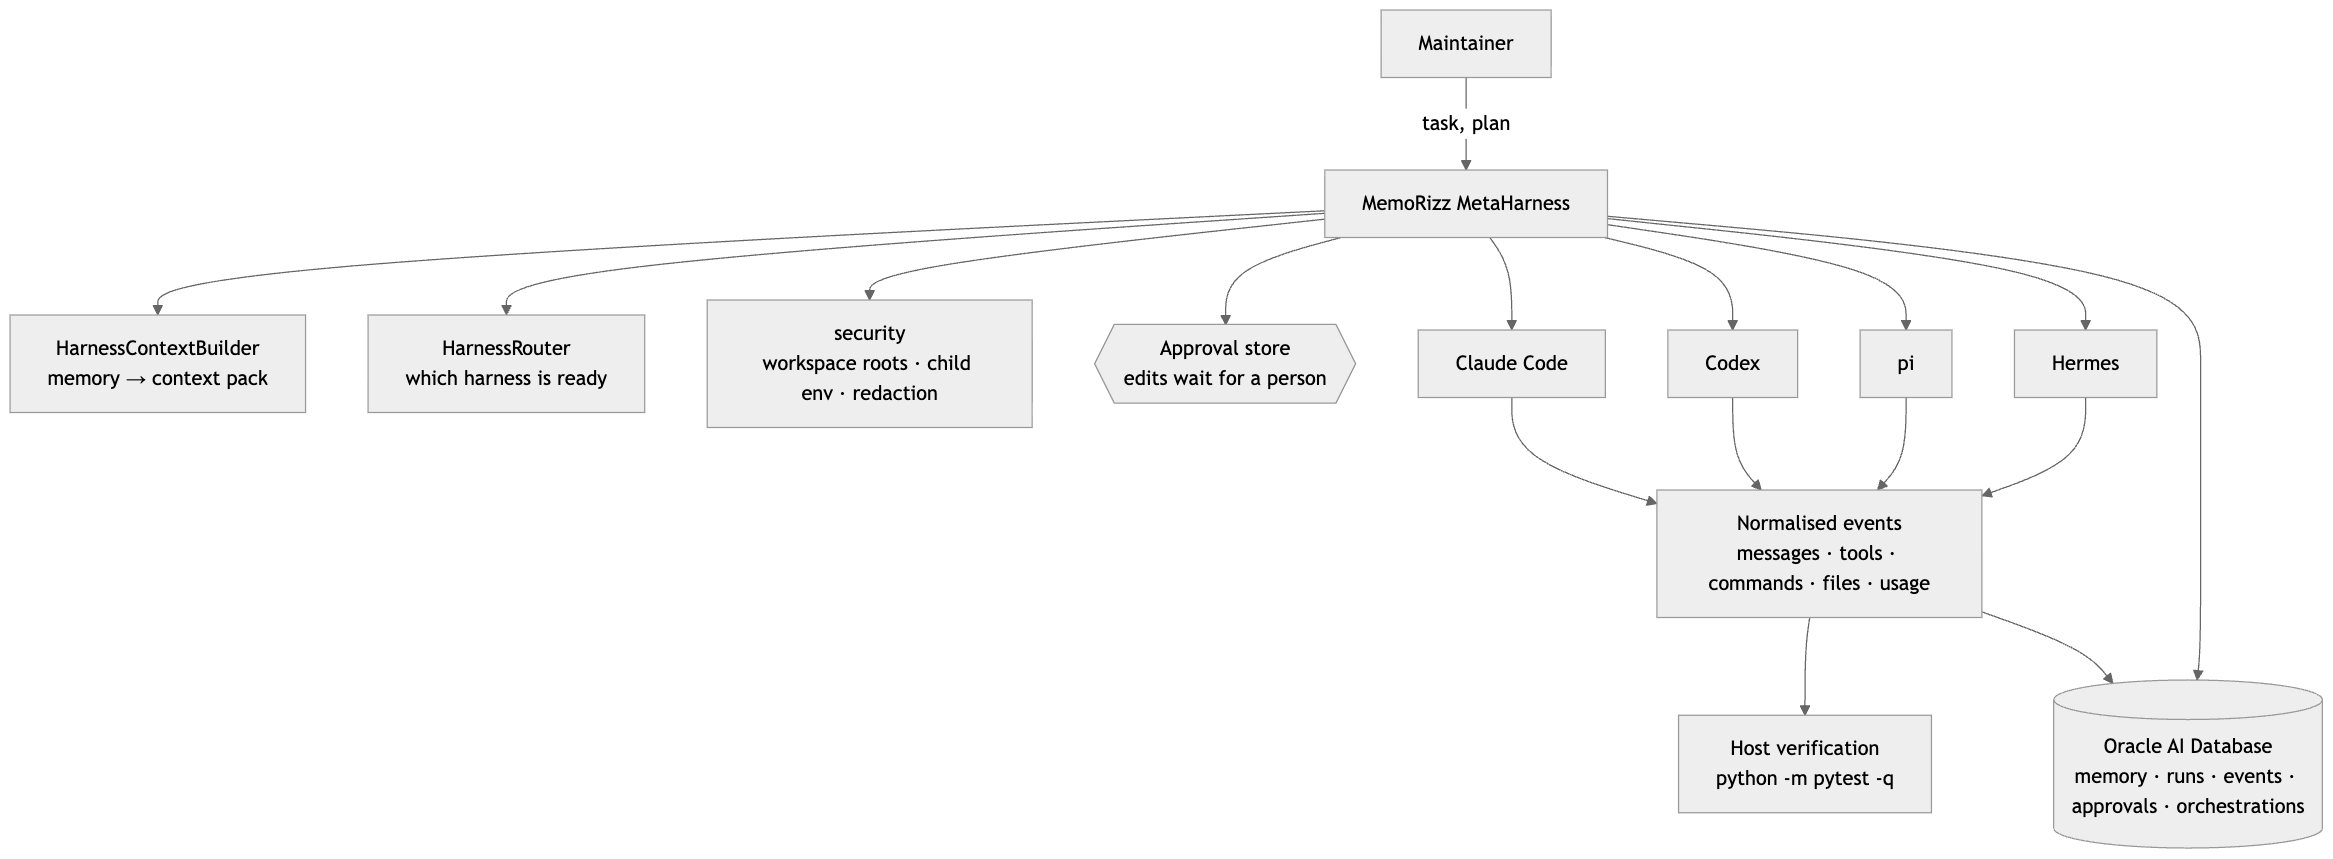

**One run through the meta-harness**

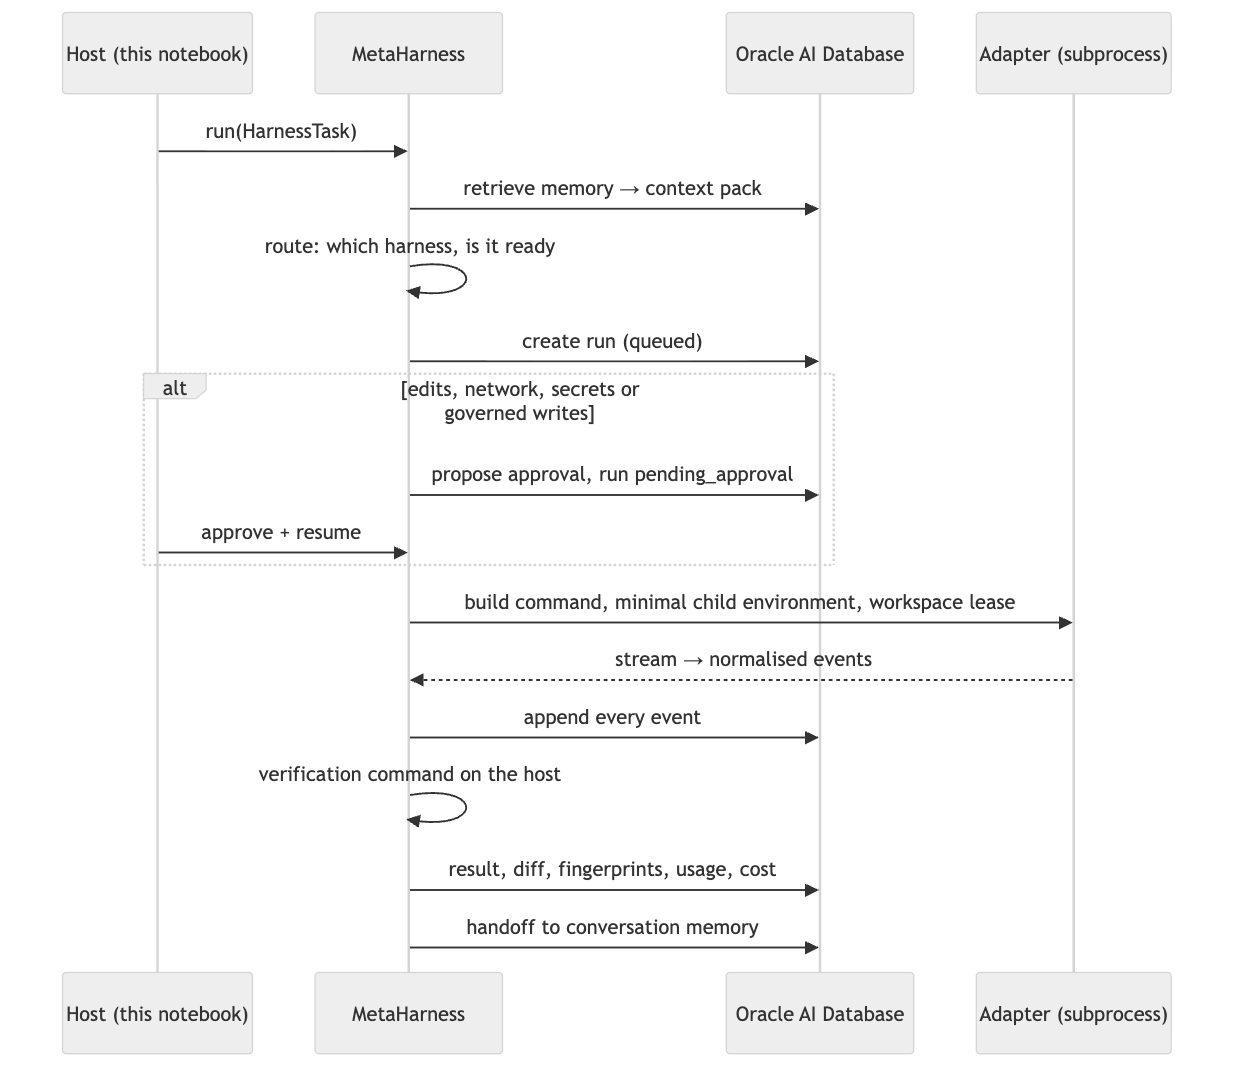


## Contents

- Part 1: Environment
- Part 2: The contract
- Part 3: Adapters and the event stream ⭐
- Part 4: Security and routing
- Part 5: Memory into context
- Part 6: Durable state in Oracle ⭐
- Part 7: One run, end to end ⭐
- Part 8: The approval gate
- Part 9: A staged plan across three harnesses ⭐
- Part 10: The same question to two harnesses
- Part 11: What the ledger holds

A star marks a part to show live; the rest is read.

## Part 1: Environment

The notebook needs Python 3.11 or newer, Oracle AI Database in Docker, an Anthropic key,
and at least one coding agent on the machine. Codex uses its own login; pi and Hermes are
installed by the done-for-you track under `part_2/harness_done_for_you/.tools`.

### 1.1 Which MemoRizz

`MEMORIZZ_SRC` names a checkout. When it is set, that source is imported; when it is not, the installed package is. The provenance line says which one is live.

In [1]:
from __future__ import annotations

import inspect, json, logging, os, re, shutil, subprocess, sys, textwrap, time, uuid, warnings
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from getpass import getpass
from pathlib import Path
from typing import Any, Dict, Optional

import oracledb, requests
oracledb.defaults.fetch_lobs = False

MEMORIZZ_SRC = os.path.expanduser(os.getenv("MEMORIZZ_SRC", "~/Desktop/memorizz/src"))
if Path(MEMORIZZ_SRC, "memorizz").is_dir():
    sys.path.insert(0, MEMORIZZ_SRC)
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

import memorizz
from importlib.metadata import version as installed_version
source = Path(memorizz.__file__).resolve()
checkout = source.parents[2] if "site-packages" not in str(source) else None
commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=checkout, capture_output=True, text=True).stdout.strip() if checkout else ""
print("memorizz", getattr(memorizz, "__version__", installed_version("memorizz")), "from",
      str(source.parent).replace(str(Path.home()), "~"))
print("development checkout at commit", commit if commit else "— installed package")

memorizz 0.12.0 from ~/Desktop/memorizz/src/memorizz
development checkout at commit fc1126c


### 1.2 Keys and the coding agents

Only the Anthropic key is asked for. Codex is used with its own login. pi and Hermes are pointed at the done-for-you track's installs; a machine without them still runs the Claude Code parts.

In [2]:
def secret(name: str, prompt: str) -> str:
    value = os.getenv(name, "").strip() or getpass(prompt).strip()
    if not value:
        raise RuntimeError(f"{name} is required for this notebook.")
    os.environ[name] = value
    return value

secret("ANTHROPIC_API_KEY", "Anthropic API key: ")
TOOLS = Path("../../../harness_done_for_you/.tools").resolve()
os.environ.setdefault("MEMORIZZ_PI_COMMAND", str(TOOLS / "node_modules" / ".bin" / "pi"))
os.environ.setdefault("MEMORIZZ_HERMES_COMMAND", str(TOOLS / "hermes-venv" / "bin" / "hermes"))
print({"pi": Path(os.environ["MEMORIZZ_PI_COMMAND"]).exists(), "hermes": Path(os.environ["MEMORIZZ_HERMES_COMMAND"]).exists()})

{'pi': True, 'hermes': True}


### 1.3 Oracle AI Database

The same schema the other Part 2 advanced lessons use, created through the container's operating-system authentication when it is missing.

In [3]:
ALREADY_THERE = ("ORA-01543", "ORA-01920", "ORA-00955", "ORA-01430", "ORA-02260")


GRANTS = ["CREATE SESSION", "CREATE TABLE", "CREATE VIEW", "CREATE PROCEDURE", "CREATE TRIGGER",
          "CREATE JOB", "CREATE MINING MODEL", "CREATE SEQUENCE", "CREATE DOMAIN", "CREATE PROPERTY GRAPH",
          "SELECT_CATALOG_ROLE",
          "EXECUTE ON DBMS_SCHEDULER", "EXECUTE ON DBMS_VECTOR", "EXECUTE ON DBMS_VECTOR_CHAIN"]


POOL = dict(min=1, max=8, increment=1, ping_interval=0,
            getmode=oracledb.POOL_GETMODE_TIMEDWAIT, wait_timeout=120_000)   # a small database can be slow under load


@dataclass(frozen=True)
class OracleConfig:
    dsn: str = os.getenv("ADV_ORA_DSN", "127.0.0.1:1524/FREEPDB1")
    user: str = os.getenv("ADV_ORA_USER", "PPA_ADVANCED")
    password: str = os.getenv("ADV_ORA_PWD", "PpaAdvanced_2026!")
    container: str = os.getenv("ADV_ORACLE_CONTAINER", "ppa-custom-oracle-26ai")
    pdb: str = os.getenv("ADV_ORA_PDB", "FREEPDB1")
    tablespace: str = os.getenv("ADV_ORA_TABLESPACE", "PPA_DATA")
    embed_model: str = "ALL_MINILM_L12_V2"
    model_cache: Path = Path(os.getenv("ADV_MODEL_CACHE", Path.home() / ".ppa_workshop" / "models"))


ORA = OracleConfig()


_pools: dict[str, oracledb.ConnectionPool] = {}

In [4]:
def reachable(timeout: float = 3.0) -> bool:
    import socket
    host, rest = ORA.dsn.split(":", 1)
    try:
        with socket.create_connection((host, int(rest.split("/")[0])), timeout=timeout):
            return True
    except OSError:
        return False


def _container_running() -> bool:
    found = subprocess.run(["docker", "inspect", "-f", "{{.State.Running}}", ORA.container],
                           capture_output=True, text=True)
    return found.returncode == 0 and found.stdout.strip() == "true"


def admin_sql(statements: list[str]) -> list[str]:
    """Run statements as the administrator. Returns the ORA- lines that were not 'already there'."""
    if _container_running():
        def block(statement: str) -> str:
            plsql = statement.lstrip().upper().startswith(("DECLARE", "BEGIN"))
            return statement.rstrip().rstrip(";") + (";\n/" if plsql else ";")
        script = "\n".join(["SET HEADING OFF FEEDBACK OFF ECHO OFF",
                            f"ALTER SESSION SET CONTAINER = {ORA.pdb};",
                            *(block(s) for s in statements), "EXIT"])
        done = subprocess.run(["docker", "exec", "-i", ORA.container, "sqlplus", "-s", "/ as sysdba"],
                              input=script, capture_output=True, text=True, timeout=300)
        return [line.strip() for line in done.stdout.splitlines()
                if line.startswith("ORA-") and not line.startswith(ALREADY_THERE)]
    password = os.getenv("ORACLE_ADMIN_PASSWORD", "")
    if not password:
        raise RuntimeError("The database container is not running here and ORACLE_ADMIN_PASSWORD is "
                           "not set, so the schema cannot be created.")
    problems = []
    with oracledb.connect(user="sys", password=password, dsn=ORA.dsn,
                          mode=oracledb.AUTH_MODE_SYSDBA) as admin, admin.cursor() as cursor:
        for statement in statements:
            try:
                cursor.execute(statement.rstrip(";"))
            except oracledb.DatabaseError as error:
                if not str(error).startswith(ALREADY_THERE):
                    problems.append(str(error).splitlines()[0])
        admin.commit()
    return problems

In [5]:
def ensure_schema() -> dict:
    """The tablespace, the user and its grants. Safe to call on every start."""
    try:
        with oracledb.connect(user=ORA.user, password=ORA.password, dsn=ORA.dsn):
            return {"user": ORA.user, "created": False}
    except oracledb.DatabaseError:
        pass
    tablespace = "\n".join([
        "DECLARE d VARCHAR2(400);",
        "BEGIN",
        "  SELECT REGEXP_REPLACE(file_name, '[^/]+$', '') INTO d FROM dba_data_files",
        "   WHERE tablespace_name = 'SYSTEM' FETCH FIRST 1 ROW ONLY;",
        f"  EXECUTE IMMEDIATE 'CREATE TABLESPACE {ORA.tablespace} DATAFILE ''' || d || "
        f"'{ORA.tablespace.lower()}01.dbf'' SIZE 512M AUTOEXTEND ON NEXT 128M MAXSIZE 8G "
        "SEGMENT SPACE MANAGEMENT AUTO';",
        "EXCEPTION WHEN OTHERS THEN IF SQLCODE NOT IN (-1543) THEN RAISE; END IF;",
        "END;"])
    problems = admin_sql([
        tablespace,
        f'CREATE USER {ORA.user} IDENTIFIED BY "{ORA.password}" '
        f"DEFAULT TABLESPACE {ORA.tablespace} QUOTA UNLIMITED ON {ORA.tablespace}",
        *(f"GRANT {grant} TO {ORA.user}" for grant in GRANTS)])
    if problems:
        raise RuntimeError("The schema could not be created: " + "; ".join(problems))
    with oracledb.connect(user=ORA.user, password=ORA.password, dsn=ORA.dsn):
        return {"user": ORA.user, "created": True}


def pool(name: str = "app", **overrides) -> oracledb.ConnectionPool:
    if name not in _pools:
        _pools[name] = oracledb.create_pool(user=ORA.user, password=ORA.password, dsn=ORA.dsn,
                                            **{**POOL, **overrides})
    return _pools[name]


def _patient(work):
    """One retry when the pool or the network let a call down; the database is small and shared."""
    import time
    try:
        return work()
    except oracledb.DatabaseError as error:
        if not str(error).startswith(("DPY-4005", "DPY-4011", "ORA-04036", "ORA-03113")):
            raise
        time.sleep(3)
        return work()


def rows(sql: str, binds=None) -> list[dict]:
    def work():
        with pool().acquire() as connection, connection.cursor() as cursor:
            cursor.execute(sql, binds or {})
            names = [column[0].lower() for column in cursor.description]
            return [dict(zip(names, record)) for record in cursor.fetchall()]
    return _patient(work)


def execute(sql: str, binds=None, many: list | None = None) -> int:
    def work():
        with pool().acquire() as connection, connection.cursor() as cursor:
            if many is not None:
                cursor.executemany(sql, many)
            else:
                cursor.execute(sql, binds or {})
            connection.commit()
            return cursor.rowcount
    return _patient(work)

In [6]:
print(ensure_schema(), "| reachable:", reachable())
print(rows("SELECT version_full AS v FROM product_component_version FETCH FIRST 1 ROW ONLY")[0]["v"])

{'user': 'PPA_ADVANCED', 'created': False} | reachable: True


23.26.0.0.0


### 1.4 A helper that shows source

The rest of the notebook reads MemoRizz's code as it is on this machine. `show` prints a numbered excerpt of a function or class, from its first line, so what is read is what runs.

In [7]:
def show(target, first: int = 1, count: int = 40, find: str | None = None) -> None:
    """Print `count` lines of `target`'s source, starting at line `first`, or at the first line that contains `find`."""
    lines, start = inspect.getsourcelines(target)
    if find is not None:
        first = next((n + 1 for n, line in enumerate(lines) if find in line), 1)
    name = getattr(target, "__qualname__", getattr(target, "__name__", str(target)))
    print(f"# {inspect.getsourcefile(target).split('memorizz/')[-1]} :: {name}  (lines {start + first - 1}–{start + min(first - 1 + count, len(lines)) - 1})")
    for n, line in enumerate(lines[first - 1:first - 1 + count], start=start + first - 1):
        print(f"{n:>5}  {line.rstrip()}")

## Part 2: The contract

Everything a harness receives and returns is a dataclass in `models.py`. A task names the
work, the workspace, the harness, the memory scope, the permissions, the budget and the
verification. A result carries the answer, the events' summary, the diff, the workspace
fingerprints before and after, usage, cost and the routing decision. Because every adapter
speaks these types, the host can compare harnesses and keep one ledger.

### 2.1 HarnessTask, HarnessPermissions, VerificationSpec, HarnessBudget

In [8]:
from memorizz import HarnessPermissions, HarnessTask, VerificationSpec
from memorizz.metaharness.models import HarnessBudget, HarnessResult, HarnessStatus

show(HarnessTask, count=46)

# metaharness/models.py :: HarnessTask  (lines 287–332)
  287  @dataclass
  288  class HarnessTask:
  289      task: str
  290      workspace: str
  291      harness: str = "auto"
  292      memory_id: Optional[str] = None
  293      user_id: Optional[str] = None
  294      thread_id: Optional[str] = None
  295      agent_id: Optional[str] = None
  296      model: Optional[str] = None
  297      mode: str = "runtime"
  298      permissions: HarnessPermissions = field(default_factory=HarnessPermissions)
  299      budget: HarnessBudget = field(default_factory=HarnessBudget)
  300      verification: VerificationSpec = field(default_factory=VerificationSpec)
  301      output_schema: Optional[Dict[str, Any]] = None
  302      context: Dict[str, Any] = field(default_factory=dict)
  303      metadata: Dict[str, Any] = field(default_factory=dict)
  304      run_id: str = field(default_factory=lambda: str(uuid.uuid4()))
  305  
  306      def __post_init__(self) -> None:
  307          self.t

In [9]:
show(HarnessPermissions, count=32)

# metaharness/models.py :: HarnessPermissions  (lines 164–195)
  164  @dataclass
  165  class HarnessPermissions:
  166      workspace_mode: str = "read_only"
  167      allowed_roots: List[str] = field(default_factory=list)
  168      allow_dirty_workspace: bool = False
  169      network: str = "none"
  170      allowed_tools: List[str] = field(default_factory=list)
  171      denied_tools: List[str] = field(default_factory=list)
  172      allowed_env: List[str] = field(default_factory=list)
  173      mcp_access: str = "read_only"
  174      require_approval: Optional[bool] = None
  175      # Let the harness start its own subagents (Claude Code's Task tool, Codex's
  176      # sub-agents). Off by default: each subagent is another model session.
  177      allow_subagents: bool = False
  178  
  179      def __post_init__(self) -> None:
  180          self.allow_subagents = bool(self.allow_subagents)
  181          self.workspace_mode = str(self.workspace_mode or "read_only").lowe

In [10]:
show(VerificationSpec, count=18)
print()
show(HarnessBudget, count=20)

# metaharness/models.py :: VerificationSpec  (lines 209–226)
  209  @dataclass
  210  class VerificationSpec:
  211      command: Optional[str] = None
  212      cwd: Optional[str] = None
  213      timeout_seconds: int = 300
  214      required: bool = False
  215  
  216      def __post_init__(self) -> None:
  217          self.timeout_seconds = max(1, min(int(self.timeout_seconds), 3_600))
  218          if self.command:
  219              self.required = True
  220  
  221      @classmethod
  222      def from_value(cls, value: Any) -> "VerificationSpec":
  223          if isinstance(value, cls):
  224              return value
  225          return cls(**dict(value or {}))
  226  

# metaharness/models.py :: HarnessBudget  (lines 132–151)
  132  @dataclass
  133  class HarnessBudget:
  134      max_wall_time_seconds: float = 900.0
  135      max_steps: int = 80
  136      max_cost_usd: Optional[float] = None
  137      max_input_tokens: Optional[int] = None
  138      max_output_t

### 2.2 The states a run can be in, and what a result carries

In [11]:
show(HarnessStatus, count=22)
print()
show(HarnessResult, count=26)

# metaharness/models.py :: HarnessStatus  (lines 32–52)
   32  class HarnessStatus(str, Enum):
   33      PENDING_APPROVAL = "pending_approval"
   34      QUEUED = "queued"
   35      RUNNING = "running"
   36      SUCCEEDED = "succeeded"
   37      FAILED = "failed"
   38      CANCELED = "canceled"
   39      INTERRUPTED = "interrupted"
   40      BUDGET_EXCEEDED = "budget_exceeded"
   41      VERIFICATION_FAILED = "verification_failed"
   42  
   43      @property
   44      def terminal(self) -> bool:
   45          return self in {
   46              self.SUCCEEDED,
   47              self.FAILED,
   48              self.CANCELED,
   49              self.INTERRUPTED,
   50              self.BUDGET_EXCEEDED,
   51              self.VERIFICATION_FAILED,
   52          }

# metaharness/models.py :: HarnessResult  (lines 432–457)
  432  @dataclass
  433  class HarnessResult:
  434      run_id: str
  435      harness: str
  436      status: HarnessStatus | str
  437      final_response:

### 2.3 One task, as the host writes it

Read-only, no network, read-only MCP, a verification command that the host runs itself. The dictionary form is what the JSON API and the CLI send.

In [12]:
WORKSPACE = Path("~/.ppa_workshop/metaharness-workspace").expanduser()
MEMORY = "tripbook-" + uuid.uuid4().hex[:6]      # one memory scope for this run of the notebook
task = HarnessTask(
    task="Read tripbook/ledger.py and the tests. Report likely defects in the idempotency rules, in three short bullets. Do not edit files.",
    workspace=str(WORKSPACE), harness="claude-code", memory_id=MEMORY, user_id="richmond", thread_id="ledger-review",
    permissions=HarnessPermissions(workspace_mode="read_only", network="none", mcp_access="read_only"),
    verification=VerificationSpec(command="python -m pytest -q"))
print(json.dumps(task.to_dict(), indent=1, default=str).replace(str(Path.home()), "~")[:1200])

{
 "task": "Read tripbook/ledger.py and the tests. Report likely defects in the idempotency rules, in three short bullets. Do not edit files.",
 "workspace": "~/.ppa_workshop/metaharness-workspace",
 "harness": "claude-code",
 "memory_id": "tripbook-3dca48",
 "user_id": "richmond",
 "thread_id": "ledger-review",
 "agent_id": null,
 "model": null,
 "mode": "runtime",
 "permissions": {
  "workspace_mode": "read_only",
  "allowed_roots": [],
  "allow_dirty_workspace": false,
  "network": "none",
  "allowed_tools": [],
  "denied_tools": [],
  "allowed_env": [],
  "mcp_access": "read_only",
  "require_approval": false,
  "allow_subagents": false
 },
 "budget": {
  "max_wall_time_seconds": 900.0,
  "max_steps": 80,
  "max_cost_usd": null,
  "max_input_tokens": null,
  "max_output_tokens": null,
  "max_event_chars": 50000,
  "max_retries": 1
 },
 "verification": {
  "command": "python -m pytest -q",
  "cwd": null,
  "timeout_seconds": 300,
  "required": true
 },
 "output_schema": null,
 "cont

## Part 3: Adapters and the event stream ⭐

An adapter wraps one vendor CLI. `AgentHarness` is the contract: `probe` says whether the
harness is ready, `run` executes a task and returns an outcome, `cancel` stops a run.
`SubprocessHarness` does the shared work: it builds the command, starts the child with a
minimal environment, reads its output stream and turns each vendor-specific line into a
normalised event. The adapters differ in `build_command` and in how they parse the stream.

In [13]:
from memorizz.metaharness.base import AgentHarness, SubprocessHarness
show(AgentHarness, count=26)

# metaharness/base.py :: AgentHarness  (lines 43–64)
   43  class AgentHarness(ABC):
   44      name: str = "base"
   45      supports_output_schema: bool = False
   46  
   47      @abstractmethod
   48      def probe(self) -> HarnessCapabilities:
   49          """Return secret-free runtime capability and health information."""
   50  
   51      @abstractmethod
   52      def run(
   53          self,
   54          task: HarnessTask,
   55          *,
   56          workspace: Path,
   57          context_pack: HarnessContextPack,
   58          emit: EventSink,
   59          cancel_event: threading.Event,
   60      ) -> AdapterOutcome:
   61          """Execute one bounded task and emit normalized events."""
   62  
   63      def cancel(self, run_id: str) -> bool:
   64          return False


### 3.1 What every subprocess harness does

In [14]:
show(SubprocessHarness.run, count=60)

# metaharness/base.py :: SubprocessHarness.run  (lines 336–395)
  336      def run(
  337          self,
  338          task: HarnessTask,
  339          *,
  340          workspace: Path,
  341          context_pack: HarnessContextPack,
  342          emit: EventSink,
  343          cancel_event: threading.Event,
  344      ) -> AdapterOutcome:
  345          capability = self.probe()
  346          if not capability.available or capability.error or not capability.command:
  347              return AdapterOutcome(
  348                  error_code=capability.error_code or "adapter_not_ready",
  349                  error=self._capability_error(capability),
  350                  remediation=capability.remediation,
  351              )
  352          prompt = self._prompt(task, context_pack)
  353          command = self.build_command(task, workspace=workspace, prompt=prompt)
  354          if not command:
  355              return AdapterOutcome(
  356                  error_code="inv

### 3.2 Two adapters, two command lines

Claude Code is run restricted: exactly the tools the policy allows, a private config directory, no OAuth fallback. Codex is run non-interactively with its own sandbox mode.

In [15]:
from memorizz.metaharness.adapters import ClaudeCodeHarness, CodexHarness, PiHarness
show(ClaudeCodeHarness.build_command, count=70)

# metaharness/adapters.py :: ClaudeCodeHarness.build_command  (lines 1211–1280)
 1211      def build_command(
 1212          self, task: HarnessTask, *, workspace: Path, prompt: str
 1213      ) -> List[str]:
 1214          restricted = self._restricted_mode()
 1215          command = [
 1216              self.command,
 1217              *(["--restricted", "--strict-mcp-config"] if restricted else ["--bare"]),
 1218              "--print",
 1219              "--output-format",
 1220              "stream-json",
 1221              "--verbose",
 1222              "--permission-mode",
 1223              "acceptEdits" if task.writes_workspace else "dontAsk",
 1224          ]
 1225          # Ephemeral runs are the safe default. A caller may explicitly retain a
 1226          # session when it intends to use the adapter checkpoint for resumption.
 1227          if not task.metadata.get("persist_session", False):
 1228              command.append("--no-session-persistence")
 1229          all

In [16]:
show(CodexHarness.build_command, count=50)

# metaharness/adapters.py :: CodexHarness.build_command  (lines 905–954)
  905      def build_command(
  906          self, task: HarnessTask, *, workspace: Path, prompt: str
  907      ) -> List[str]:
  908          sandbox = "workspace-write" if task.writes_workspace else "read-only"
  909          command = [
  910              self.command,
  911              "exec",
  912              "--json",
  913              "--ignore-user-config",
  914              "--ignore-rules",
  915              "--skip-git-repo-check",
  916              "--sandbox",
  917              sandbox,
  918              "--cd",
  919              str(workspace),
  920          ]
  921          # Sub-agents hang off a saved parent session; an ephemeral run's
  922          # spawns fail with "no thread with id".
  923          if not task.metadata.get("persist_session", False) and not (
  924              task.permissions.allow_subagents
  925          ):
  926              command.insert(3, "--ephemeral")
 

### 3.3 The normalised events

Whatever a vendor prints, the host stores messages, tool calls and results, commands, file changes, usage and errors under one enumeration.

In [17]:
from memorizz.metaharness.models import HarnessEvent, HarnessEventType
show(HarnessEventType, count=24)

# metaharness/models.py :: HarnessEventType  (lines 55–69)
   55  class HarnessEventType(str, Enum):
   56      STATUS = "status"
   57      MESSAGE = "message"
   58      # A harness's own reasoning, as far as it reports it (summaries or text).
   59      REASONING = "reasoning"
   60      TOOL_CALL = "tool_call"
   61      TOOL_RESULT = "tool_result"
   62      COMMAND = "command"
   63      FILE_CHANGE = "file_change"
   64      USAGE = "usage"
   65      APPROVAL = "approval"
   66      VERIFICATION = "verification"
   67      ERROR = "error"
   68      COMPLETE = "complete"
   69      LOG = "log"


### 3.4 Which harnesses are ready here ⭐

`probe` runs the vendor's own readiness check and reports a secret-free error contract when something is missing.

In [18]:
from memorizz.metaharness import MetaHarness
doctor = MetaHarness.from_env(allowed_workspace_roots=[str(WORKSPACE.parent)])
for name in ["claude-code", "codex", "pi", "hermes", "deepseek", "openhands"]:
    found = doctor.probe(name)
    print(f"{name:<12} ready={found.get('ready')!s:<6} {str(found.get('error') or found.get('remediation') or '')[:80]}")

claude-code  ready=True   


codex        ready=True   


pi           ready=True   


hermes       ready=True   
deepseek     ready=False  DEEPSEEK_API_KEY is not set.
openhands    ready=False  'openhands' is not installed or not executable


## Part 4: Security and routing

Before a child process starts, the host decides where it may work, what it may see and
which harness will run it. `resolve_workspace` refuses a path outside the allowed roots.
`build_child_environment` passes only what the adapter needs. `redact` keeps credential
values out of every event that is stored. `HarnessRouter` chooses a ready harness for
`auto` and fails closed when the named one is not ready.

In [19]:
from memorizz.metaharness import security
show(security.resolve_workspace, count=28)

# metaharness/security.py :: resolve_workspace  (lines 148–172)
  148  def resolve_workspace(workspace: str, allowed_roots: Iterable[str] = ()) -> Path:
  149      roots = [Path(root).expanduser().resolve(strict=True) for root in allowed_roots]
  150      allowed = (
  151          " Allowed workspace roots: " + ", ".join(str(root) for root in roots) + "."
  152          if roots
  153          else ""
  154      )
  155      try:
  156          path = Path(workspace).expanduser().resolve(strict=True)
  157      except (FileNotFoundError, NotADirectoryError):
  158          raise HarnessSecurityError(
  159              f"Workspace {workspace} does not exist on this machine. Use the "
  160              f"absolute path of an existing folder.{allowed}"
  161          ) from None
  162      if not path.is_dir():
  163          raise HarnessSecurityError(
  164              f"Workspace {path} is not a folder. Use the absolute path of an "
  165              f"existing folder.{allowed}"
  

In [20]:
show(security.build_child_environment, count=18)
print()
show(security.redact, count=18)

# metaharness/security.py :: build_child_environment  (lines 131–145)
  131  def build_child_environment(
  132      *,
  133      allowed_names: Iterable[str] = (),
  134      overrides: Optional[Mapping[str, str]] = None,
  135  ) -> Dict[str, str]:
  136      names = set(_BASE_ENV)
  137      names.update(str(item) for item in allowed_names if str(item).strip())
  138      result = {name: os.environ[name] for name in names if name in os.environ}
  139      for key, value in dict(overrides or {}).items():
  140          if _SENSITIVE_KEYS.search(str(key)) and key not in names:
  141              raise HarnessSecurityError(
  142                  f"Secret environment variable {key!r} was not explicitly allowlisted"
  143              )
  144          result[str(key)] = str(value)
  145      return result

# metaharness/security.py :: redact  (lines 81–96)
   81  def redact(value: Any) -> Any:
   82      if isinstance(value, Mapping):
   83          return {
   84              str(key)

### 4.1 The workspace fingerprint

A snapshot of the tree before and after a run is how the host knows what a harness changed, and how an approval becomes invalid when the workspace changed underneath it.

In [21]:
show(security.workspace_snapshot, count=40)

# metaharness/security.py :: workspace_snapshot  (lines 280–319)
  280  def workspace_snapshot(
  281      workspace: Path, *, include_untracked_contents: bool = False
  282  ) -> Dict[str, Any]:
  283      head_code, head, _ = _run_git(workspace, "rev-parse", "HEAD")
  284      status_code, status, _ = _run_git(
  285          workspace, "status", "--porcelain=v1", "--untracked-files=all"
  286      )
  287      diff_code, diff, _ = _run_git(workspace, "diff", "--binary", "HEAD")
  288      git_repo = head_code == 0 and status_code == 0
  289      status_digest = hashlib.sha256(status.encode("utf-8")).hexdigest()
  290      diff_digest = hashlib.sha256(diff.encode("utf-8")).hexdigest()
  291      untracked_digest = (
  292          _untracked_content_digest(workspace) if include_untracked_contents else None
  293      )
  294      tree_digest = (
  295          _workspace_tree_digest(workspace)
  296          if include_untracked_contents and not git_repo
  297          else None
  29

In [22]:
from memorizz.metaharness.router import HarnessRouter
show(HarnessRouter, find="def route", count=44)

# metaharness/router.py :: HarnessRouter  (lines 60–103)
   60  class HarnessRouter:
   61      """Stable router; an LLM never authorizes or overrides this policy."""
   62  
   63      def __init__(
   64          self,
   65          *,
   66          preference: Iterable[str] = (
   67              "memagent",
   68              "codex",
   69              "claude-code",
   70              "openhands",
   71              "deepseek",
   72              "pi",
   73              "hermes",
   74          ),
   75          allowlist: Optional[Iterable[str]] = None,
   76      ) -> None:
   77          self.preference = [str(item).lower() for item in preference]
   78          self.allowlist = (
   79              {str(item).lower() for item in allowlist} if allowlist is not None else None
   80          )
   81  
   82      def select(
   83          self,
   84          task: HarnessTask,
   85          adapters: Mapping[str, AgentHarness],
   86          *,
   87          metrics: Opti

## Part 5: Memory into context

The meta-harness is memory-first. Before a harness starts, `HarnessContextBuilder` asks
the memory provider for what is known about this scope, ranks it, fits it into a bounded
pack, and fingerprints the pack, so two stages of one plan, or two harnesses in one
comparison, can be shown byte-identical evidence.

In [23]:
from memorizz.metaharness.context import HarnessContextBuilder
show(HarnessContextBuilder.build, count=58)

# metaharness/context.py :: HarnessContextBuilder.build  (lines 131–188)
  131      def build(
  132          self,
  133          query: str,
  134          *,
  135          memory_id: Optional[str],
  136          user_id: Optional[str],
  137          thread_id: Optional[str],
  138          memory_types: Iterable[MemoryType] = _CONTEXT_TYPES,
  139          exclude: Optional[Callable[[Dict[str, Any]], bool]] = None,
  140      ) -> HarnessContextPack:
  141          """Retrieve, bound and render memory for ``query``.
  142  
  143          ``exclude`` drops rows before they count, e.g. a benchmark task's own
  144          earlier lessons, so a later attempt cannot read its answer.
  145          """
  146          records: List[Dict[str, Any]] = []
  147          seen = set()
  148          excluded = 0
  149          for memory_type in memory_types:
  150              for row in self._retrieve(
  151                  query,
  152                  memory_type,
  153              

### 5.1 The memory provider on Oracle AI Database

MemoRizz's `OracleProvider` keeps every memory type in Oracle with vectors made inside the
database. One patch is needed on the Free *lite* image: the provider reads existing
`VECTOR` column dimensions through `DBMS_METADATA`, which needs XDB, and the lite image
has no XDB. The data dictionary already has the answer in `USER_TAB_COLS.VECTOR_INFO`.

In [24]:
def vector_dimensions_from_dictionary(self) -> Dict[str, int]:
    owner = str(self.config.schema or self.config.user).strip().upper()
    dimensions: Dict[str, int] = {}
    with self._get_connection() as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT table_name, column_name, vector_info FROM all_tab_cols "
                       "WHERE owner = :owner AND data_type = 'VECTOR' AND column_name = 'EMBEDDING'", {"owner": owner})
        for table_name, column_name, info in cursor.fetchall():
            found = re.search(r"VECTOR\((\d+)", str(info or ""))
            if found:
                dimensions[f"{table_name}.{column_name}"] = int(found.group(1))
        cursor.close()
    return dimensions


def patch_oracle_provider() -> None:
    from memorizz.memory_provider.oracle import provider
    provider.OracleProvider.get_vector_schema_dimensions = vector_dimensions_from_dictionary

In [25]:
patch_oracle_provider()
from memorizz.memory_provider.oracle import OracleConfig, OracleProvider
provider = OracleProvider(OracleConfig(user=ORA.user, password=ORA.password, dsn=ORA.dsn,
                                       in_database_embedding=True, pool_max=4))
print("vector columns seen:", len(provider.get_vector_schema_dimensions()))

vector columns seen: 13


## Part 6: Durable state in Oracle ⭐

MemoRizz ships its run ledger and its approval queue on SQLite, for one local worker. Both
are small protocols, so the host can keep the same records in the database it already
runs on. The run store holds runs, their events, workspace leases and orchestrations; the
approval store holds proposals with a single-use id, an argument hash and an expiry. Rows
carry the record as JSON beside the columns that are queried.

In [26]:
from memorizz.metaharness.store import HarnessRunStore
show(HarnessRunStore, count=60)

# metaharness/store.py :: HarnessRunStore  (lines 21–76)
   21  class HarnessRunStore(Protocol):
   22      def create(self, run: HarnessRun) -> HarnessRun:
   23          ...
   24  
   25      def get(self, run_id: str) -> Optional[HarnessRun]:
   26          ...
   27  
   28      def list(
   29          self, *, limit: int = 100, status: Optional[str] = None
   30      ) -> List[HarnessRun]:
   31          ...
   32  
   33      def update(self, run_id: str, **changes: Any) -> HarnessRun:
   34          ...
   35  
   36      def append_event(self, event: HarnessEvent) -> HarnessEvent:
   37          ...
   38  
   39      def events(
   40          self, run_id: str, *, after: int = 0, limit: int = 1000
   41      ) -> List[HarnessEvent]:
   42          ...
   43  
   44      def acquire_workspace(self, workspace: str, run_id: str) -> bool:
   45          ...
   46  
   47      def release_workspace(self, workspace: str, run_id: str) -> None:
   48          ...
   49  
   50     

In [27]:
from memorizz.approval import (ApprovalMismatch, ApprovalNotFound, ApprovalProposal, ApprovalStateError,
                               ApprovalStatus, argument_hash, canonical_arguments)
from memorizz.metaharness.models import HarnessOrchestration, HarnessRun, utcnow_iso

In [28]:
def _dump(value: Any) -> str:
    return json.dumps(value, ensure_ascii=False, sort_keys=True, default=str)


def _now() -> datetime:
    return datetime.now(timezone.utc)


def _iso(value: datetime | None) -> str | None:
    return value.isoformat() if value else None


def _when(value: Any) -> datetime | None:
    if value is None:
        return None
    if isinstance(value, datetime):
        return value if value.tzinfo else value.replace(tzinfo=timezone.utc)
    return datetime.fromisoformat(str(value))


class OracleTables:
    """What the two stores share: a pool, a prefix and idempotent DDL."""

    def __init__(self, pool: Any, prefix: str = "MH") -> None:
        self.pool, self.prefix = pool, prefix.upper()
        self._create()

    def table(self, name: str) -> str:
        return f"{self.prefix}_{name}"

    def _ddl(self, cursor: Any, statement: str) -> None:
        try:
            cursor.execute(statement)
        except oracledb.DatabaseError as error:
            if not str(error).startswith(ALREADY_THERE):
                raise

    def _create(self) -> None:
        t = self.table
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            self._ddl(cursor, f"""CREATE TABLE {t('RUNS')} (
                run_id VARCHAR2(80) PRIMARY KEY, status VARCHAR2(30) NOT NULL, harness VARCHAR2(60),
                created_at VARCHAR2(40) NOT NULL, updated_at VARCHAR2(40) NOT NULL, payload CLOB NOT NULL)""")
            self._ddl(cursor, f"""CREATE TABLE {t('EVENTS')} (
                run_id VARCHAR2(80) NOT NULL, sequence NUMBER NOT NULL, timestamp VARCHAR2(40) NOT NULL,
                event_type VARCHAR2(60) NOT NULL, item_id VARCHAR2(200), payload CLOB NOT NULL,
                CONSTRAINT {t('EVENTS')}_PK PRIMARY KEY (run_id, sequence))""")
            self._ddl(cursor, f"""CREATE TABLE {t('LEASES')} (
                workspace VARCHAR2(1000) PRIMARY KEY, run_id VARCHAR2(80) NOT NULL, acquired_at VARCHAR2(40) NOT NULL)""")
            self._ddl(cursor, f"""CREATE TABLE {t('ORCHESTRATIONS')} (
                orchestration_id VARCHAR2(80) PRIMARY KEY, kind VARCHAR2(20) NOT NULL, status VARCHAR2(30) NOT NULL,
                created_at VARCHAR2(40) NOT NULL, updated_at VARCHAR2(40) NOT NULL, payload CLOB NOT NULL)""")
            self._ddl(cursor, f"""CREATE TABLE {t('APPROVALS')} (
                proposal_id VARCHAR2(80) PRIMARY KEY, owner_id VARCHAR2(200) NOT NULL, tool_name VARCHAR2(200) NOT NULL,
                arguments_json CLOB NOT NULL, argument_hash VARCHAR2(128) NOT NULL, policy_reason VARCHAR2(2000) NOT NULL,
                checkpoint_json CLOB NOT NULL, status VARCHAR2(20) NOT NULL, created_at VARCHAR2(40) NOT NULL,
                expires_at VARCHAR2(40) NOT NULL, approver_id VARCHAR2(200), decision_reason VARCHAR2(2000),
                decided_at VARCHAR2(40), consumed_at VARCHAR2(40))""")
            connection.commit()

### 6.1 Runs

Create, read, list and update. An update is a read-modify-write under a row lock, so two hosts cannot erase each other's change.

In [29]:
class OracleRuns(OracleTables):
    """Runs: create, read, list, update."""

    def create(self, run: HarnessRun) -> HarnessRun:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"INSERT INTO {self.table('RUNS')} (run_id, status, harness, created_at, updated_at, payload) "
                           "VALUES (:1, :2, :3, :4, :5, :6)",
                           [run.run_id, run.status.value, run.harness, run.created_at, run.updated_at, _dump(run.to_dict())])
            connection.commit()
        return run

    def get(self, run_id: str) -> HarnessRun | None:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT payload FROM {self.table('RUNS')} WHERE run_id = :1", [str(run_id)])
            row = cursor.fetchone()
        return HarnessRun(**json.loads(row[0])) if row else None

    def list(self, *, limit: int = 100, status: str | None = None) -> list[HarnessRun]:
        where = " WHERE status = :status" if status else ""
        binds = {"limit": max(1, min(int(limit), 10_000)), **({"status": str(status)} if status else {})}
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT payload FROM {self.table('RUNS')}{where} ORDER BY updated_at DESC "
                           "FETCH FIRST :limit ROWS ONLY", binds)
            return [HarnessRun(**json.loads(row[0])) for row in cursor.fetchall()]

    def update(self, run_id: str, **changes: Any) -> HarnessRun:
        """A read-modify-write under a row lock, so two hosts cannot erase each other's change."""
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT payload FROM {self.table('RUNS')} WHERE run_id = :1 FOR UPDATE", [str(run_id)])
            row = cursor.fetchone()
            if row is None:
                raise KeyError(f"Unknown harness run: {run_id}")
            payload = HarnessRun(**json.loads(row[0])).to_dict()
            payload.update(changes)
            payload["updated_at"] = utcnow_iso()
            updated = HarnessRun(**payload)
            cursor.execute(f"UPDATE {self.table('RUNS')} SET status = :1, harness = :2, updated_at = :3, payload = :4 "
                           "WHERE run_id = :5", [updated.status.value, updated.harness, updated.updated_at,
                                                  _dump(updated.to_dict()), updated.run_id])
            connection.commit()
        return updated

### 6.2 Events and workspace leases

Events are numbered per run as they are appended. A lease is one row per workspace, so two runs cannot edit the same tree at once.

In [30]:
class OracleEvents(OracleTables):
    """Events: numbered per run as they are appended."""

    def append_event(self, event: HarnessEvent) -> HarnessEvent:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            if event.sequence is None:
                cursor.execute(f"SELECT COALESCE(MAX(sequence), 0) FROM {self.table('EVENTS')} WHERE run_id = :1",
                               [event.run_id])
                event.sequence = int(cursor.fetchone()[0]) + 1
            item = (event.data or {}).get("id") if isinstance(event.data, dict) else None
            cursor.execute(f"INSERT INTO {self.table('EVENTS')} (run_id, sequence, timestamp, event_type, item_id, payload) "
                           "VALUES (:1, :2, :3, :4, :5, :6)",
                           [event.run_id, event.sequence, event.timestamp, event.type.value,
                            str(item)[:200] if item else None, _dump(event.to_dict())])
            connection.commit()
        return event

    def events(self, run_id: str, *, after: int = 0, limit: int = 1000) -> list[HarnessEvent]:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT payload FROM {self.table('EVENTS')} WHERE run_id = :1 AND sequence > :2 "
                           "ORDER BY sequence FETCH FIRST :3 ROWS ONLY",
                           [str(run_id), max(0, int(after)), max(1, min(int(limit), 10_000))])
            return [HarnessEvent(**json.loads(row[0])) for row in cursor.fetchall()]

    def event_counts(self, run_ids: list[str]) -> dict[str, dict[str, int]]:
        ids = [str(r) for r in run_ids if r][:1000]
        if not ids:
            return {}
        marks = ", ".join(f":i{n}" for n in range(len(ids)))
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT run_id, event_type, COUNT(DISTINCT COALESCE(item_id, TO_CHAR(sequence))) "
                           f"FROM {self.table('EVENTS')} WHERE run_id IN ({marks}) GROUP BY run_id, event_type",
                           {f"i{n}": r for n, r in enumerate(ids)})
            counts: dict[str, dict[str, int]] = {}
            for run_id, kind, n in cursor.fetchall():
                counts.setdefault(run_id, {})[kind] = int(n)
        return counts


class OracleLeases(OracleTables):
    """Workspace leases: one row per workspace, so two runs cannot edit the same tree at once."""

    def acquire_workspace(self, workspace: str, run_id: str) -> bool:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            try:
                cursor.execute(f"INSERT INTO {self.table('LEASES')} (workspace, run_id, acquired_at) VALUES (:1, :2, :3)",
                               [str(workspace), str(run_id), utcnow_iso()])
                connection.commit()
                return True
            except oracledb.IntegrityError:
                connection.rollback()
                return False

    def release_workspace(self, workspace: str, run_id: str) -> None:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"DELETE FROM {self.table('LEASES')} WHERE workspace = :1 AND run_id = :2",
                           [str(workspace), str(run_id)])
            connection.commit()

### 6.3 Orchestrations, recovery, and the store itself

A plan or a comparison is a record with steps. A host that starts marks what its last life left running as interrupted.

In [31]:
class OracleOrchestrations(OracleTables):
    """Plans and comparisons: a record with steps, updated under a row lock."""

    def create_orchestration(self, orchestration: HarnessOrchestration) -> HarnessOrchestration:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"INSERT INTO {self.table('ORCHESTRATIONS')} (orchestration_id, kind, status, created_at, "
                           "updated_at, payload) VALUES (:1, :2, :3, :4, :5, :6)",
                           [orchestration.orchestration_id, orchestration.kind, orchestration.status.value,
                            orchestration.created_at, orchestration.updated_at, _dump(orchestration.to_dict())])
            connection.commit()
        return orchestration

    def get_orchestration(self, orchestration_id: str) -> HarnessOrchestration | None:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT payload FROM {self.table('ORCHESTRATIONS')} WHERE orchestration_id = :1",
                           [str(orchestration_id)])
            row = cursor.fetchone()
        return HarnessOrchestration(**json.loads(row[0])) if row else None

    def list_orchestrations(self, *, limit: int = 50, status: str | None = None) -> list[HarnessOrchestration]:
        where = " WHERE status = :status" if status else ""
        binds = {"limit": max(1, min(int(limit), 10_000)), **({"status": str(status)} if status else {})}
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT payload FROM {self.table('ORCHESTRATIONS')}{where} ORDER BY updated_at DESC "
                           "FETCH FIRST :limit ROWS ONLY", binds)
            return [HarnessOrchestration(**json.loads(row[0])) for row in cursor.fetchall()]

    def update_orchestration(self, orchestration_id: str, **changes: Any) -> HarnessOrchestration:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"SELECT payload FROM {self.table('ORCHESTRATIONS')} WHERE orchestration_id = :1 FOR UPDATE",
                           [str(orchestration_id)])
            row = cursor.fetchone()
            if row is None:
                raise KeyError(f"Unknown orchestration: {orchestration_id}")
            payload = HarnessOrchestration(**json.loads(row[0])).to_dict()
            payload.update(changes)
            payload["updated_at"] = utcnow_iso()
            updated = HarnessOrchestration(**payload)
            cursor.execute(f"UPDATE {self.table('ORCHESTRATIONS')} SET status = :1, updated_at = :2, payload = :3 "
                           "WHERE orchestration_id = :4",
                           [updated.status.value, updated.updated_at, _dump(updated.to_dict()), updated.orchestration_id])
            connection.commit()
        return updated


class OracleHarnessRunStore(OracleRuns, OracleEvents, OracleLeases, OracleOrchestrations):
    """The MemoRizz ``HarnessRunStore`` protocol on Oracle AI Database: the four parts, and recovery."""

    def recover_interrupted(self) -> int:
        """A host that starts finds what its last life left running and says so."""
        recovered = 0
        for run in self.list(limit=10_000):
            if run.status in {HarnessStatus.RUNNING, HarnessStatus.QUEUED}:
                self.update(run.run_id, status=HarnessStatus.INTERRUPTED.value, finished_at=utcnow_iso(),
                            result={"ok": False, "status": HarnessStatus.INTERRUPTED.value, "error_code": "host_restarted",
                                    "error": "The harness host restarted during this run."})
                recovered += 1
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"DELETE FROM {self.table('LEASES')}")
            connection.commit()
        for orchestration in self.list_orchestrations(limit=10_000):
            if not orchestration.status.terminal:
                self.update_orchestration(orchestration.orchestration_id, status=HarnessStatus.INTERRUPTED.value,
                                          finished_at=utcnow_iso(), error_code="host_restarted",
                                          error="The harness host restarted during this workflow.")
        return recovered

    def close(self) -> None:
        """The pool belongs to the caller."""

### 6.4 The approval queue

A proposal is pending, approved, rejected, expired or consumed. Approving and consuming happen under a row lock; consuming checks the tool name and the argument hash.

In [32]:
class OracleProposals(OracleTables):
    """Proposals: propose, read, list, with expiry applied on every read."""

    COLUMNS = ("proposal_id", "owner_id", "tool_name", "arguments_json", "argument_hash", "policy_reason",
               "checkpoint_json", "status", "created_at", "expires_at", "approver_id", "decision_reason",
               "decided_at", "consumed_at")

    def _proposal(self, row: tuple) -> ApprovalProposal:
        r = dict(zip(self.COLUMNS, row))
        return ApprovalProposal(proposal_id=r["proposal_id"], owner_id=r["owner_id"], tool_name=r["tool_name"],
                                arguments=json.loads(r["arguments_json"]), argument_hash=r["argument_hash"],
                                policy_reason=r["policy_reason"], status=ApprovalStatus(r["status"]),
                                created_at=_when(r["created_at"]), expires_at=_when(r["expires_at"]),
                                checkpoint=json.loads(r["checkpoint_json"] or "{}"), approver_id=r["approver_id"],
                                decision_reason=r["decision_reason"], decided_at=_when(r["decided_at"]),
                                consumed_at=_when(r["consumed_at"]))

    def _expire(self, cursor: Any) -> None:
        cursor.execute(f"UPDATE {self.table('APPROVALS')} SET status = :1 WHERE status IN (:2, :3) AND expires_at <= :4",
                       [ApprovalStatus.EXPIRED.value, ApprovalStatus.PENDING.value, ApprovalStatus.APPROVED.value,
                        _iso(_now())])

    def _select(self) -> str:
        return f"SELECT {', '.join(self.COLUMNS)} FROM {self.table('APPROVALS')}"

    def propose(self, *, owner_id: str, tool_name: str, arguments: dict, policy_reason: str,
                checkpoint: dict | None = None, ttl_seconds: int = 900) -> ApprovalProposal:
        created = _now()
        expires = created + timedelta(seconds=max(1, min(int(ttl_seconds), 86_400)))
        proposal_id = str(uuid.uuid4())
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            cursor.execute(f"INSERT INTO {self.table('APPROVALS')} (proposal_id, owner_id, tool_name, arguments_json, "
                           "argument_hash, policy_reason, checkpoint_json, status, created_at, expires_at) "
                           "VALUES (:1, :2, :3, :4, :5, :6, :7, :8, :9, :10)",
                           [proposal_id, owner_id.strip(), tool_name.strip(), canonical_arguments(arguments),
                            argument_hash(tool_name.strip(), arguments), policy_reason.strip(),
                            json.dumps(dict(checkpoint or {}), ensure_ascii=False, sort_keys=True, separators=(",", ":")),
                            ApprovalStatus.PENDING.value, _iso(created), _iso(expires)])
            connection.commit()
        return self.get(proposal_id)

    def get(self, proposal_id: str) -> ApprovalProposal | None:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            self._expire(cursor)
            connection.commit()
            cursor.execute(f"{self._select()} WHERE proposal_id = :1", [str(proposal_id or "").strip()])
            row = cursor.fetchone()
        return self._proposal(row) if row else None

    def list(self, *, owner_id: str | None = None, status: Any = None, limit: int = 100) -> list[ApprovalProposal]:
        clauses, binds = [], {"limit": max(1, min(int(limit), 1000))}
        if owner_id:
            clauses.append("owner_id = :owner"); binds["owner"] = owner_id
        if status:
            clauses.append("status = :status"); binds["status"] = status.value if isinstance(status, ApprovalStatus) else str(status)
        where = (" WHERE " + " AND ".join(clauses)) if clauses else ""
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            self._expire(cursor)
            connection.commit()
            cursor.execute(f"{self._select()}{where} ORDER BY created_at DESC FETCH FIRST :limit ROWS ONLY", binds)
            return [self._proposal(row) for row in cursor.fetchall()]

In [33]:
class OracleDecisions(OracleProposals):
    """Decisions: approve or reject once, consume once, under a row lock."""

    def _decide(self, proposal_id: str, status: ApprovalStatus, *, approver_id: str,
                decision_reason: str | None) -> ApprovalProposal:
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            self._expire(cursor)
            cursor.execute(f"SELECT status FROM {self.table('APPROVALS')} WHERE proposal_id = :1 FOR UPDATE", [proposal_id])
            row = cursor.fetchone()
            if not row:
                connection.rollback()
                raise ApprovalNotFound(f"Unknown approval proposal '{proposal_id}'")
            if ApprovalStatus(row[0]) != ApprovalStatus.PENDING:
                connection.rollback()
                raise ApprovalStateError(f"Approval proposal '{proposal_id}' is {row[0]}, not pending")
            cursor.execute(f"UPDATE {self.table('APPROVALS')} SET status = :1, approver_id = :2, decision_reason = :3, "
                           "decided_at = :4 WHERE proposal_id = :5",
                           [status.value, approver_id.strip(), (decision_reason or "").strip() or None, _iso(_now()), proposal_id])
            connection.commit()
        return self.get(proposal_id)

    def approve(self, proposal_id: str, *, approver_id: str, decision_reason: str | None = None) -> ApprovalProposal:
        return self._decide(proposal_id, ApprovalStatus.APPROVED, approver_id=approver_id, decision_reason=decision_reason)

    def reject(self, proposal_id: str, *, approver_id: str, decision_reason: str | None = None) -> ApprovalProposal:
        return self._decide(proposal_id, ApprovalStatus.REJECTED, approver_id=approver_id, decision_reason=decision_reason)

    def consume(self, proposal_id: str, *, expected_tool_name: str | None = None,
                expected_arguments: dict | None = None) -> ApprovalProposal:
        """An approval is spent exactly once, and only for the call it was given for."""
        with self.pool.acquire() as connection, connection.cursor() as cursor:
            self._expire(cursor)
            cursor.execute(f"{self._select()} WHERE proposal_id = :1 FOR UPDATE", [proposal_id])
            row = cursor.fetchone()
            if not row:
                connection.rollback()
                raise ApprovalNotFound(f"Unknown approval proposal '{proposal_id}'")
            proposal = self._proposal(row)
            if proposal.status != ApprovalStatus.APPROVED:
                connection.rollback()
                raise ApprovalStateError(f"Approval proposal '{proposal_id}' is {proposal.status.value}, not approved")
            if expected_tool_name is not None and proposal.tool_name != str(expected_tool_name).strip():
                connection.rollback()
                raise ApprovalMismatch("Approved tool name does not match the checkpoint")
            if expected_arguments is not None and proposal.argument_hash != argument_hash(proposal.tool_name, expected_arguments):
                connection.rollback()
                raise ApprovalMismatch("Approved arguments do not match the checkpoint")
            cursor.execute(f"UPDATE {self.table('APPROVALS')} SET status = :1, consumed_at = :2 "
                           "WHERE proposal_id = :3 AND status = :4",
                           [ApprovalStatus.CONSUMED.value, _iso(_now()), proposal_id, ApprovalStatus.APPROVED.value])
            if cursor.rowcount != 1:
                connection.rollback()
                raise ApprovalStateError("Approval was already consumed")
            connection.commit()
        return self.get(proposal_id)


class OracleApprovalStore(OracleDecisions):
    """The MemoRizz ``ApprovalStore`` protocol on Oracle AI Database."""

    def close(self) -> None:
        """The pool belongs to the caller."""

### 6.5 Assemble the meta-harness ⭐

`from_env` registers the adapters it can find. The stores and the provider are passed in, and the workspace root is the only place a harness may work.

In [34]:
RUNS = OracleHarnessRunStore(pool("mh", max=4), prefix="MH")
APPROVALS = OracleApprovalStore(pool("mh", max=4), prefix="MH")
meta = MetaHarness.from_env(memory_provider=provider, run_store=RUNS, approval_store=APPROVALS,
                            allowed_workspace_roots=[str(WORKSPACE.parent)])
print("adapters:", sorted(meta.adapters), "| interrupted runs recovered at start:", meta.recovered_runs)
print("tables:", [t["table_name"] for t in rows("SELECT table_name FROM user_tables WHERE REGEXP_LIKE(table_name, '^MH_') ORDER BY 1")])

adapters: ['claude-code', 'codex', 'deepseek', 'hermes', 'memagent', 'openhands', 'pi'] | interrupted runs recovered at start: 0


tables: ['MH_APPROVALS', 'MH_EVENTS', 'MH_LEASES', 'MH_ORCHESTRATIONS', 'MH_RUNS']


## Part 7: One run, end to end ⭐

`MetaHarness.run` is the sequence the whole lesson is about: scope the task, retrieve
memory, route, apply policy, pause for approval when the task needs authority, execute
through the adapter, verify on the host, record everything. Read it first, then run it.

In [35]:
show(MetaHarness.run, count=70)

# metaharness/service.py :: MetaHarness.run  (lines 487–540)
  487      def run(self, task: HarnessTask | Dict[str, Any]) -> HarnessResult:
  488          resolved_input = (
  489              task if isinstance(task, HarnessTask) else HarnessTask.from_dict(task)
  490          )
  491          try:
  492              task_value, workspace, before, routing = self._prepare(resolved_input)
  493          except Exception as exc:
  494              error_code, error, remediation, routing = self._preparation_failure(exc)
  495              failed = HarnessResult(
  496                  run_id=resolved_input.run_id,
  497                  harness=resolved_input.harness,
  498                  status=HarnessStatus.FAILED,
  499                  routing=routing,
  500                  error_code=error_code,
  501                  error=error,
  502                  remediation=remediation,
  503              )
  504              self._create_run(
  505                  resolved_input, status=

### 7.1 The workspace

A small project written into a scratch folder, as a git repository, so a harness's edits can be diffed and nothing in the course is touched. The defect is planted in `book()`.

In [36]:
LEDGER_SOURCE = '''"""A booking ledger with idempotency keys."""
from __future__ import annotations

import hashlib
from dataclasses import dataclass, field


@dataclass
class Booking:
    booking_id: str
    component: str
    offer_id: str
    status: str
    confirmation: str
    reason: str = ""


@dataclass
class Ledger:
    bookings: dict[str, Booking] = field(default_factory=dict)      # idempotency key -> booking

    @staticmethod
    def key(trip_id: str, component: str, offer_id: str, attempt: int = 0) -> str:
        return f"{trip_id}:{component}:{offer_id}:{attempt}"

    def book(self, trip_id: str, component: str, offer_id: str, attempt: int = 0) -> Booking:
        """The same request twice returns the first confirmation."""
        key = self.key(trip_id, component, offer_id, attempt)
        if key in self.bookings:
            return self.bookings[key]
        confirmation = "CONF-" + hashlib.sha256(key.encode()).hexdigest()[:8].upper()
        booking = Booking(f"BK-{len(self.bookings) + 1:04d}", component, offer_id, "CONFIRMED", confirmation)
        self.bookings[key] = booking
        return booking

    def cancel(self, booking_id: str, reason: str) -> None:
        for booking in self.bookings.values():
            if booking.booking_id == booking_id and booking.status == "CONFIRMED":
                booking.status = "CANCELLED"
                booking.reason = reason

    def confirmed(self) -> list[Booking]:
        return [b for b in self.bookings.values() if b.status == "CONFIRMED"]
'''


TEST_SOURCE = '''from tripbook.ledger import Ledger


def test_the_same_request_is_one_booking():
    ledger = Ledger()
    first = ledger.book("T1", "flight", "OF-1")
    again = ledger.book("T1", "flight", "OF-1")
    assert first.confirmation == again.confirmation
    assert len(ledger.confirmed()) == 1


def test_cancel_marks_the_booking():
    ledger = Ledger()
    booking = ledger.book("T1", "hotel", "OF-2")
    ledger.cancel(booking.booking_id, "sold out elsewhere")
    assert ledger.confirmed() == []
'''

In [37]:
FILES = {
    "README.md": """# tripbook

A booking ledger for a trip-booking workflow. `book()` must be idempotent: the same
request twice returns the first confirmation. `cancel()` marks a booking cancelled.

Run the tests with `python -m pytest -q`.
""",
    "tripbook/__init__.py": "",
    "tripbook/ledger.py": LEDGER_SOURCE,
    "tests/test_ledger.py": TEST_SOURCE,
    "pyproject.toml": '[tool.pytest.ini_options]\npythonpath = ["."]\n',
}


def write_workspace(folder: Path, git: bool = True) -> Path:
    """A fresh copy of the project, as a git repository so a harness's edits can be diffed."""
    if folder.exists():
        shutil.rmtree(folder)
    for name, text in FILES.items():
        path = folder / name
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(text)
    if git:
        subprocess.run(["git", "init", "-q"], cwd=folder, check=True)
        subprocess.run(["git", "add", "-A"], cwd=folder, check=True)
        subprocess.run(["git", "-c", "user.name=workshop", "-c", "user.email=workshop@example.com", "commit", "-q",
                        "-m", "tripbook: a booking ledger"], cwd=folder, check=True)
    return folder

In [38]:
write_workspace(WORKSPACE)
print(subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=WORKSPACE, capture_output=True, text=True).stdout.strip().splitlines()[-1])
print((WORKSPACE / "tripbook" / "ledger.py").read_text().split("def book")[1][:420])

2 passed in 0.01s
(self, trip_id: str, component: str, offer_id: str, attempt: int = 0) -> Booking:
        """The same request twice returns the first confirmation."""
        key = self.key(trip_id, component, offer_id, attempt)
        if key in self.bookings:
            return self.bookings[key]
        confirmation = "CONF-" + hashlib.sha256(key.encode()).hexdigest()[:8].upper()
        booking = Booking(f"BK-{len(self.bookings)


### 7.2 Run it on Claude Code ⭐

In [39]:
started = time.perf_counter()
result = meta.run(task)
print(f"{time.perf_counter() - started:.0f} s | {result.harness} | status {result.status.value} | ok {result.ok} | "
      f"verified {result.verified} | cost {result.cost_usd} USD | routing {result.routing.get('reason', '')[:60]}")
print()
print(result.final_response[:1500])

34 s | claude-code | status succeeded | ok True | verified True | cost 0.1019446 USD | routing explicit caller override passed capability and policy checks

I found three likely defects in the idempotency rules in `tripbook/ledger.py`:

- **A retry is treated as a new request (`ledger.py:23-24`).** The retry counter `attempt` is part of the idempotency key. So if a caller retries after a timeout and increases the counter (`attempt=1`), the ledger treats it as a new request and creates a second booking with a second confirmation. A retry should reuse the original key; the attempt number belongs in logs, not in the key.

- **A cancelled booking is replayed as if it still counts (`ledger.py:29-30`, `36-40`).** After `cancel()`, sending the same request again finds the existing key and silently returns the cancelled `Booking`. The caller gets a confirmation number back and has no signal that the booking is void, and there is no way to book that offer again. It also hands back the stored ob

### 7.3 What was recorded

The run row, its events, the verification and the context pack that was shown to the harness, all from Oracle.

In [40]:
run = RUNS.get(result.run_id)
events = RUNS.events(result.run_id)
kinds = {}
for event in events:
    kinds[event.type.value] = kinds.get(event.type.value, 0) + 1
print("run:", run.status.value, "| events:", len(events), kinds)
print("verification:", json.dumps(result.verification, default=str).replace(str(Path.home()), "~")[:240])
print("context pack:", {"records": len(result.context_pack.records) if result.context_pack else 0,
                        "fingerprint": (result.context_pack.fingerprint if result.context_pack else "")[:16]})
print(rows("SELECT run_id, status, harness, created_at FROM mh_runs ORDER BY created_at DESC FETCH FIRST 3 ROWS ONLY"))

run: succeeded | events: 19 {'status': 4, 'log': 4, 'tool_call': 3, 'tool_result': 3, 'reasoning': 1, 'message': 1, 'complete': 2, 'verification': 1}
verification: {"required": true, "verified": true, "command": "python -m pytest -q", "cwd": "~/.ppa_workshop/metaharness-workspace", "return_code": 0, "stdout": "..                                                                       [100%]\n2 passed in
context pack: {'records': 0, 'fingerprint': '259b3942a92daac2'}
[{'run_id': '75c995c7-d802-450f-99f1-a019a3d0ba58', 'status': 'succeeded', 'harness': 'claude-code', 'created_at': '2026-09-30T12:49:07.840938+00:00'}, {'run_id': 'e583daad-d94d-429b-a095-9b9e4384b343', 'status': 'succeeded', 'harness': 'claude-code', 'created_at': '2026-09-30T11:56:40.489591+00:00'}, {'run_id': '9d8a5b91-f106-4831-beb6-ff6df32c8a3f', 'status': 'succeeded', 'harness': 'pi', 'created_at': '2026-09-30T11:56:40.254756+00:00'}]


## Part 8: The approval gate

A task that can change the workspace, use the network, see a secret or write through a
governed MCP capability does not start. The host records a proposal that binds the tool
name, the complete arguments, the workspace fingerprint, the permissions, the budgets and
the verification to a single-use id with an expiry, and the run waits as
`pending_approval`. Approval executes the original checkpoint; the model is never asked
to reconstruct approved arguments, and a workspace that changed in the meantime makes
the approval invalid.

In [41]:
show(MetaHarness.approve, count=44)

# metaharness/service.py :: MetaHarness.approve  (lines 602–610)
  602      def approve(
  603          self, proposal_id: str, *, approver_id: str, reason: Optional[str] = None
  604      ) -> Dict[str, Any]:
  605          proposal = self.approval_store.approve(
  606              proposal_id,
  607              approver_id=approver_id,
  608              decision_reason=reason,
  609          )
  610          return proposal.to_dict(include_arguments=True)


In [42]:
show(MetaHarness.resume_approval, count=14)
print()
show(APPROVALS.consume, count=30)

# metaharness/service.py :: MetaHarness.resume_approval  (lines 749–762)
  749      def resume_approval(self, proposal_id: str) -> HarnessResult:
  750          """Consume and synchronously execute one approved exact checkpoint."""
  751          task, workspace, current, routing, failure = self._consume_approved_checkpoint(
  752              proposal_id
  753          )
  754          if failure is not None:
  755              return failure
  756          assert task is not None and workspace is not None and current is not None
  757          return self._execute(
  758              task,
  759              workspace=workspace,
  760              before=current,
  761              routing=dict(routing or {}),
  762          )

# /var/folders/q5/mqxgw8bd5t3b68thxd06mpnm0000gn/T/ipykernel_51591/467719416.py :: OracleDecisions.consume  (lines 28–55)
   28      def consume(self, proposal_id: str, *, expected_tool_name: str | None = None,
   29                  expected_arguments: dict |

## Part 9: A staged plan across three harnesses ⭐

`start_plan` runs stages in order, each on its own harness, and returns at once with a
durable record. A background driver in the host process starts each run and keeps the
record current. When a stage finishes, its events are reduced to a **handoff**: the answer,
the changed files, the recent commands, the verification result. The next stage receives
every earlier handoff, fitted to a budget, so the first plan is never silently dropped.
The memory scope is the one this notebook created, so the plan also sees the read-only
review from Part 7 and nothing from earlier runs.
A stage that needs approval waits for the host; the plan stops at the first stage that
does not succeed.

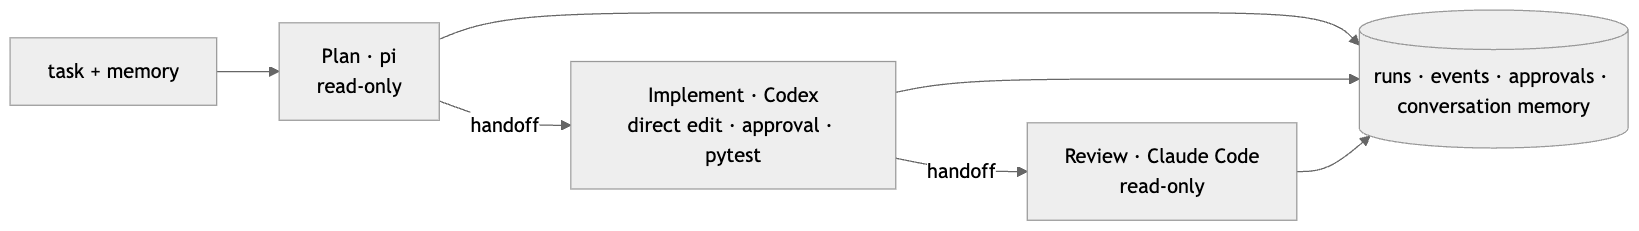

In [43]:
show(MetaHarness._drive_plan, count=62)

# metaharness/service.py :: MetaHarness._drive_plan  (lines 2168–2228)
 2168      def _drive_plan(
 2169          self,
 2170          orchestration_id: str,
 2171          base: HarnessTask,
 2172          steps: List[Dict[str, Any]],
 2173          stop: threading.Event,
 2174      ) -> None:
 2175          handoffs: List[Dict[str, Any]] = []
 2176          total = len(steps)
 2177          for index, step in enumerate(steps):
 2178              label = f"Stage {index + 1} of {total} ({step.get('name')})"
 2179              if stop.is_set():
 2180                  raise _OrchestrationStopped()
 2181              if self._orchestration_cancel_requested(orchestration_id):
 2182                  self._finish_orchestration(
 2183                      orchestration_id,
 2184                      HarnessStatus.CANCELED,
 2185                      error_code="canceled",
 2186                      error=f"Canceled before {label.lower()} started.",
 2187                  )
 2188              

In [44]:
from memorizz.metaharness import handoff
show(handoff.stage_handoff, count=50)

# metaharness/handoff.py :: stage_handoff  (lines 103–152)
  103  def stage_handoff(
  104      run: Mapping[str, Any],
  105      events: Iterable[Mapping[str, Any]],
  106      *,
  107      name: Optional[str] = None,
  108  ) -> Dict[str, Any]:
  109      """Reduce one finished harness run to the evidence the next stage needs."""
  110      result = _mapping(run.get("result"))
  111      task = _mapping(run.get("task"))
  112      files: List[str] = []
  113      commands: List[str] = []
  114      last_message = ""
  115      edit_tools = {"edit", "write", "multiedit", "str_replace_editor", "apply_patch"}
  116      for event in events:
  117          kind = str(event.get("type") or "")
  118          data = _mapping(event.get("data"))
  119          if kind == "file_change":
  120              files.extend(_paths(data))
  121          elif kind == "tool_call" and str(data.get("name") or "").lower() in edit_tools:
  122              files.extend(_paths(data))
  123          elif k

### 9.1 Start the plan ⭐

The fix from the use case: three stages, one edit stage with a verification command.

In [45]:
write_workspace(WORKSPACE)
FIX = ("In tripbook/ledger.py, a booking that was cancelled is replayed by book() as if it were still confirmed. "
       "Booking the same offer again after a cancel must create a new confirmed booking. Keep the change minimal, "
       "keep the public API, and keep python -m pytest -q green.")
plan = meta.start_plan(
    {"task": FIX, "workspace": str(WORKSPACE), "memory_id": MEMORY, "user_id": "richmond", "thread_id": "ledger-fix"},
    [{"name": "Plan", "harness": "pi", "instruction": "Write a short plan for the fix and the test to add. Do not edit files."},
     {"name": "Implement", "harness": "codex", "workspace_mode": "direct", "verification": {"command": "python -m pytest -q"}},
     {"name": "Review", "harness": "claude-code",
      "instruction": f"Review the change made in this workspace against this task: {FIX} Do not edit files. "
                     "Say whether the change is correct and minimal."}])
ORCHESTRATION = plan["orchestration_id"]
print(ORCHESTRATION, plan["status"], [s["name"] + ":" + s["harness"] for s in plan["steps"]])

eb16e5f5-4b88-4dd4-bf4a-492754c6eafb queued ['Plan:pi', 'Implement:codex', 'Review:claude-code']


### 9.2 Watch it, and approve the edit ⭐

The host polls the record. When the Codex stage proposes its edit, the host approves it and resumes the run. Nothing else is decided by a person.

In [46]:
started, approved = time.perf_counter(), set()
while True:
    time.sleep(5)
    record = meta.get_orchestration(ORCHESTRATION)
    for proposal in APPROVALS.list(status="pending"):
        if proposal.proposal_id not in approved:
            approved.add(proposal.proposal_id)
            print(f"[{time.perf_counter() - started:4.0f} s] approval needed: {proposal.tool_name} — {proposal.policy_reason[:90]}")
            meta.approve(proposal.proposal_id, approver_id="richmond@workshop")
            meta.resume_approval_start(proposal.proposal_id)
    stages = " | ".join(f"{s['name']}: {RUNS.get(s['run_id']).status.value if s.get('run_id') else '-'}" for s in record["steps"])
    print(f"[{time.perf_counter() - started:4.0f} s] {record['status']:<16} {stages}")
    if record["status"] in {"succeeded", "failed", "canceled", "interrupted"} or time.perf_counter() - started > 900:
        break

[   5 s] running          Plan: running | Implement: - | Review: -


[  10 s] running          Plan: running | Implement: - | Review: -


[  15 s] running          Plan: running | Implement: - | Review: -


[  20 s] approval needed: metaharness.run — The external harness can modify a workspace or use network, secrets, governed MCP capabili
[  21 s] pending_approval Plan: succeeded | Implement: queued | Review: -


[  26 s] running          Plan: succeeded | Implement: running | Review: -


...

[  81 s] running          Plan: succeeded | Implement: succeeded | Review: running


[  86 s] running          Plan: succeeded | Implement: succeeded | Review: running


[  91 s] running          Plan: succeeded | Implement: succeeded | Review: running


[  96 s] running          Plan: succeeded | Implement: succeeded | Review: succeeded


[ 101 s] succeeded        Plan: succeeded | Implement: succeeded | Review: succeeded


### 9.3 What each stage said, and what changed

In [47]:
for step in record["steps"]:
    run = RUNS.get(step["run_id"])
    result = run.result or {}
    print(f"== {step['name']} on {run.harness}: {run.status.value} | verified {result.get('verified')} | "
          f"cost {result.get('cost_usd')} USD | {result.get('latency_ms')} ms")
    print(textwrap.indent((result.get("final_response") or "")[:600], "   "))
    print()
implemented = RUNS.get(record["steps"][1]["run_id"]).result or {}
print((implemented.get("workspace_diff") or "no diff recorded")[:1600])

== Plan on pi: succeeded | verified False | cost 0.064905 USD | 15264 ms
   The task doesn't name a specific bug, so this plan rests on what I found in the code. I haven't run anything or edited any files.

   **Likely defect** (`tripbook/ledger.py`): `Ledger.key()` includes `attempt` in the idempotency key. A retry of the same request with `attempt=1` therefore creates a second booking and a new confirmation. That breaks the README's rule that the same request twice returns the first confirmation. The existing test misses this because it only uses the default `attempt=0`.

   A related problem is that `book()` returns the cached booking even after it has been cancelled. I'

== Implement on codex: succeeded | verified True | cost 0.210732 USD | 41816 ms
   Fixed `book()` to replay only confirmed bookings. Booking after cancellation now creates a new confirmed booking, with the public API unchanged.

   Added a regression test that failed before the fix and passes afterward.

   Verific

### 9.4 The handoffs in conversation memory

Each stage's handoff was written to the memory scope, so later runs in the same scope receive it in their context pack.

In [48]:
print(rows("SELECT COUNT(*) AS turns FROM conversation_memory WHERE memory_id = :m", {"m": MEMORY}))
for turn in rows("SELECT SUBSTR(content, 1, 160) AS c FROM conversation_memory WHERE memory_id = :m "
                 "ORDER BY timestamp DESC FETCH FIRST 3 ROWS ONLY", {"m": MEMORY}):
    print("-", turn["c"].replace("\n", " "))
print(rows("SELECT orchestration_id, kind, status FROM mh_orchestrations ORDER BY created_at DESC FETCH FIRST 3 ROWS ONLY"))
print(rows("SELECT tool_name, status, approver_id FROM mh_approvals ORDER BY created_at DESC FETCH FIRST 3 ROWS ONLY"))

[{'turns': 4}]
- [Harness plan stage 3/3: Review · claude-code · succeeded] I don't think the change is correct yet. It fixes the bug the task names, but it adds a new one: two 
- [Harness plan stage 2/3: Implement · codex · succeeded] Fixed `book()` to replay only confirmed bookings. Booking after cancellation now creates a new confirmed
- [Harness plan stage 1/3: Plan · pi · succeeded] The task doesn't name a specific bug, so this plan rests on what I found in the code. I haven't run anything or 
[{'orchestration_id': 'eb16e5f5-4b88-4dd4-bf4a-492754c6eafb', 'kind': 'plan', 'status': 'succeeded'}, {'orchestration_id': 'b959a738-446c-46e0-88be-bcbf0d3d14e4', 'kind': 'compare', 'status': 'succeeded'}, {'orchestration_id': '489f256c-c6ce-4405-a8d7-e4d969799e22', 'kind': 'plan', 'status': 'succeeded'}]
[{'tool_name': 'metaharness.run', 'status': 'consumed', 'approver_id': 'richmond@workshop'}, {'tool_name': 'metaharness.run', 'status': 'consumed', 'approver_id': 'richmond@workshop'}, {'to

## Part 10: The same question to two harnesses

A comparison runs one read-only task on several harnesses at the same time, with the same
context pack, and finishes `failed` when any of them fails. It is the simplest fair
experiment a meta-harness makes possible: same task, same evidence, different agent.

In [49]:
show(MetaHarness._drive_compare, count=40)

# metaharness/service.py :: MetaHarness._drive_compare  (lines 2230–2269)
 2230      def _drive_compare(
 2231          self,
 2232          orchestration_id: str,
 2233          base: HarnessTask,
 2234          steps: List[Dict[str, Any]],
 2235          stop: threading.Event,
 2236      ) -> None:
 2237          tasks: Dict[int, HarnessTask] = {}
 2238          for index in range(len(steps)):
 2239              if stop.is_set():
 2240                  raise _OrchestrationStopped()
 2241              if self._orchestration_cancel_requested(orchestration_id):
 2242                  break
 2243              tasks[index] = self._orchestration_task(
 2244                  base, orchestration_id, "compare", index, steps
 2245              )
 2246              run = self.start(tasks[index])
 2247              steps[index]["run_id"] = run.run_id
 2248              self.run_store.update_orchestration(orchestration_id, steps=steps)
 2249          run_ids = [step["run_id"] for step in steps if

In [50]:
compare = meta.start_compare(
    {"task": "Where can tripbook/ledger.py lose or double a booking? Answer in three bullets, no edits.",
     "workspace": str(WORKSPACE), "memory_id": MEMORY, "user_id": "richmond", "thread_id": "ledger-compare"},
    ["pi", "claude-code"])
COMPARE = compare["orchestration_id"]
started = time.perf_counter()
while True:
    time.sleep(5)
    record = meta.get_orchestration(COMPARE)
    if record["status"] in {"succeeded", "failed", "canceled", "interrupted"} or time.perf_counter() - started > 600:
        break
print(f"{time.perf_counter() - started:.0f} s | {record['status']}")
for step in record["steps"]:
    run = RUNS.get(step["run_id"])
    result = run.result or {}
    print(f"\n== {run.harness}: {run.status.value} | cost {result.get('cost_usd')} USD | {result.get('latency_ms')} ms")
    print(textwrap.indent((result.get("final_response") or "")[:500], "   "))

25 s | succeeded

== pi: succeeded | cost 0.02358525 USD | 10070 ms
   - **Doubling via the attempt counter:** `key()` includes `attempt`. A caller retry that bumps `attempt` gets a new key, so it creates a second CONFIRMED booking for the same trip, component and offer. Idempotency only holds if the caller reuses the same attempt value.
   - **Overwrite after cancellation:** `book()` replays only CONFIRMED entries. If the stored booking is CANCELLED, it makes a new booking and overwrites `self.bookings[key]`. The cancelled record then disappears from the ledger, alon

== claude-code: succeeded | cost 0.038921 USD | 19356 ms
   Three places in `tripbook/ledger.py` where a booking can be doubled or lost. I read the code but didn't run anything and made no edits.

   - **Doubling: the idempotency key isn't really one booking (`ledger.py:23-24`).** The key includes `attempt`, and also `offer_id`. So a retry of the same request with `attempt=1` gets a new key, skips the replay check at lin

## Part 11: What the ledger holds

Every run, event, approval and orchestration of this notebook is in Oracle AI Database.
This part reads them back the way an operations console would.

In [51]:
print(rows("SELECT harness, status, COUNT(*) AS runs FROM mh_runs GROUP BY harness, status ORDER BY harness, status"))
print(rows("SELECT event_type, COUNT(*) AS n FROM mh_events GROUP BY event_type ORDER BY n DESC"))
for run in RUNS.list(limit=6):
    result = run.result or {}
    print(f"{run.run_id[:8]}  {run.harness:<12} {run.status.value:<16} cost {result.get('cost_usd')}  "
          f"usage {json.dumps(result.get('usage') or {})[:60]}")

[{'harness': 'claude-code', 'status': 'interrupted', 'runs': 1}, {'harness': 'claude-code', 'status': 'succeeded', 'runs': 14}, {'harness': 'codex', 'status': 'succeeded', 'runs': 6}, {'harness': 'pi', 'status': 'succeeded', 'runs': 9}]
[{'event_type': 'status', 'n': 129}, {'event_type': 'log', 'n': 114}, {'event_type': 'tool_call', 'n': 89}, {'event_type': 'tool_result', 'n': 89}, {'event_type': 'complete', 'n': 44}, {'event_type': 'command', 'n': 44}, {'event_type': 'usage', 'n': 40}, {'event_type': 'message', 'n': 40}, {'event_type': 'file_change', 'n': 18}, {'event_type': 'verification', 'n': 12}, {'event_type': 'reasoning', 'n': 11}, {'event_type': 'approval', 'n': 6}]
f2161cb6  claude-code  succeeded        cost 0.038921  usage {"cache_creation_input_tokens": 1584, "cache_read_input_toke
0fbfa5a3  pi           succeeded        cost 0.02358525  usage {"cache_creation_input_tokens": 983, "cached_input_tokens": 
bda89807  claude-code  succeeded        cost 0.0716604  usage {"cache_c

### 11.1 Close

The pools are closed. The tables stay, so the next run of the notebook starts by recovering nothing and reading everything.

In [52]:
provider.close() if hasattr(provider, "close") else None
for name, found in list(_pools.items()):
    found.close(force=True); _pools.pop(name, None)
print("closed")

closed


## Key takeaways

1. **A meta-harness normalises, it does not replace.** Each vendor keeps its own loop; the
   host owns the task contract, the permissions, the memory, the events, the approval and
   the evidence, and every harness speaks the same types.
2. **Readiness is a probe, not a hope.** `probe` runs the vendor's own check and reports a
   secret-free error contract, so a missing login is a structured failure, not a stack trace.
3. **Security happens before the child starts.** Workspace roots, a minimal child
   environment, redaction of every stored event, and a fingerprint of the tree before and
   after.
4. **Approval binds the exact call.** The proposal holds the arguments and the workspace
   fingerprint; approval executes that checkpoint and nothing else, once.
5. **Memory is the shared evidence.** One ranked, bounded context pack per task, reused
   byte-identical across the stages of a plan and the harnesses of a comparison.
6. **Handoffs are structured, not pasted.** A stage passes its answer, changed files,
   commands and verification result to the next, fitted to a budget, and into memory.
7. **Durable state can live where the rest of the application lives.** The run ledger and
   the approval queue are small protocols; this notebook keeps them in Oracle AI Database.

## From the checkout to the package

Unset `MEMORIZZ_SRC`, or point it at an empty path, and the notebook imports the installed
`memorizz`. Everything above reads its source through `inspect`, so the excerpts always
show the code that is running.